In [ ]:
# Cell: Set up Kaggle auth (new token method)
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_a39c201a1e792518c8bf7e4727b7c033'

!pip install kaggle -q

# Cell: Download the Walmart dataset
!kaggle datasets download -d yasserh/walmart-dataset
!unzip -o walmart-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/yasserh/walmart-dataset
License(s): CC0-1.0
100% 122k/122k [00:00<00:00, 77.2MB/s]

Archive:  walmart-dataset.zip
  inflating: Walmart.csv             


In [ ]:
import pandas as pd

df = pd.read_csv('Walmart.csv')
print(df.shape)
df.head()

(6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
!ls


sample_data  Walmart.csv  walmart-dataset.zip


In [ ]:
# Check data types and missing values
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB

Missing values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicate rows: 0


In [ ]:
# Convert Date to actual datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Sort by Store and Date (important for time series!)
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# Check it worked
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# Extract useful time features from Date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


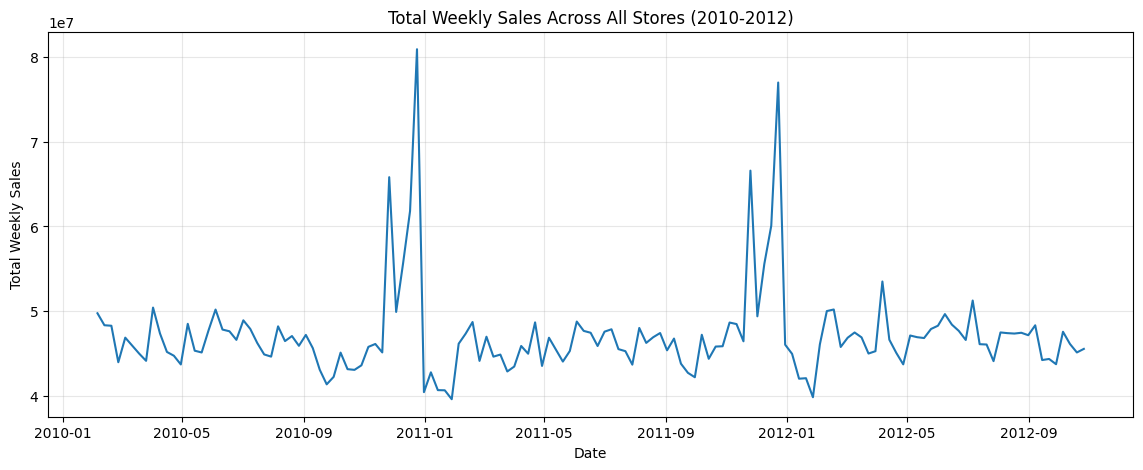

In [ ]:
import matplotlib.pyplot as plt

# Total sales across all stores, per week
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(weekly_total.index, weekly_total.values)
plt.title('Total Weekly Sales Across All Stores (2010-2012)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(True, alpha=0.3)
plt.show()

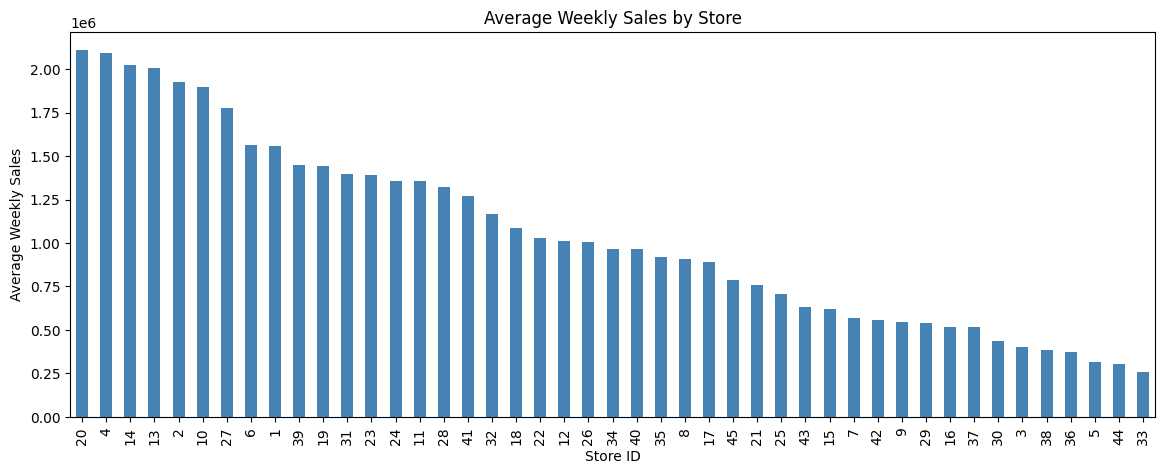

Highest avg sales store: 20 -> 2107677.0
Lowest avg sales store: 33 -> 259862.0


In [ ]:
# Average weekly sales per store, sorted
store_avg = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
store_avg.plot(kind='bar', color='steelblue')
plt.title('Average Weekly Sales by Store')
plt.xlabel('Store ID')
plt.ylabel('Average Weekly Sales')
plt.show()

print("Highest avg sales store:", store_avg.idxmax(), "->", round(store_avg.max(),0))
print("Lowest avg sales store:", store_avg.idxmin(), "->", round(store_avg.min(),0))

In [ ]:
holiday_comparison = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
print(holiday_comparison)

pct_increase = ((holiday_comparison[1] - holiday_comparison[0]) / holiday_comparison[0]) * 100
print(f"\nHoliday weeks have {pct_increase:.1f}% higher average sales than non-holiday weeks")

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

Holiday weeks have 7.8% higher average sales than non-holiday weeks


In [ ]:
df['Date'].dt.strftime('%Y-%m-%d')
holiday_dates = df[df['Holiday_Flag']==1]['Date'].dt.strftime('%Y-%m-%d').unique()
print(sorted(holiday_dates))

holiday_breakdown = df[df['Holiday_Flag']==1].groupby('Date')['Weekly_Sales'].mean()
print("\n", holiday_breakdown)

['2010-02-12', '2010-09-10', '2010-11-26', '2010-12-31', '2011-02-11', '2011-09-09', '2011-11-25', '2011-12-30', '2012-02-10', '2012-09-07']

 Date
2010-02-12    1.074148e+06
2010-09-10    1.014098e+06
2010-11-26    1.462689e+06
2010-12-31    8.985004e+05
2011-02-11    1.051915e+06
2011-09-09    1.039183e+06
2011-11-25    1.479858e+06
2011-12-30    1.023166e+06
2012-02-10    1.111320e+06
2012-09-07    1.074001e+06
Name: Weekly_Sales, dtype: float64


In [ ]:
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
correlation = df[corr_cols].corr()['Weekly_Sales'].sort_values(ascending=False)
print(correlation)

Weekly_Sales    1.000000
Fuel_Price      0.009464
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Name: Weekly_Sales, dtype: float64


In [ ]:
# Create lag features: last week's sales for each store (sorted by Store, Date already)
df['Sales_Lag1'] = df.groupby('Store')['Weekly_Sales'].shift(1)

# Rolling average: average of last 4 weeks per store
df['Sales_RollingMean4'] = df.groupby('Store')['Weekly_Sales'].shift(1).rolling(4).mean()

# Check the result
df[['Store', 'Date', 'Weekly_Sales', 'Sales_Lag1', 'Sales_RollingMean4']].head(10)

,Store,Date,Weekly_Sales,Sales_Lag1,Sales_RollingMean4
0,1,2010-02-05,1643690.90,NaN,NaN
1,1,2010-02-12,1641957.44,1643690.90,NaN
2,1,2010-02-19,1611968.17,1641957.44,NaN
3,1,2010-02-26,1409727.59,1611968.17,NaN
4,1,2010-03-05,1554806.68,1409727.59,1.576836e+06
5,1,2010-03-12,1439541.59,1554806.68,1.554615e+06
6,1,2010-03-19,1472515.79,1439541.59,1.504011e+06
7,1,2010-03-26,1404429.92,1472515.79,1.469148e+06
8,1,2010-04-02,1594968.28,1404429.92,1.467823e+06
9,1,2010-04-09,1545418.53,1594968.28,1.477864e+06


In [ ]:
# Add more time-based features
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Flag specifically for Thanksgiving week (since we proved this is THE driver)
df['IsThanksgiving'] = df['Date'].dt.strftime('%Y-%m-%d').isin(
    ['2010-11-26', '2011-11-25']
).astype(int)

# Drop rows with NaN (first 4 weeks per store - we have 45 stores, so ~180 rows lost, acceptable)
df_model = df.dropna().reset_index(drop=True)

print("Original rows:", len(df))
print("Rows after dropping NaN:", len(df_model))
df_model.head()

Original rows: 6435
Rows after dropping NaN: 6255


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Sales_Lag1,Sales_RollingMean4,WeekOfYear,IsThanksgiving
0,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1409727.59,1.576836e+06,9,0
1,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,10,1554806.68,1.554615e+06,10,0
2,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,11,1439541.59,1.504011e+06,11,0
3,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,12,1472515.79,1.469148e+06,12,0
4,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,13,1404429.92,1.467823e+06,13,0


In [ ]:
# For time series, we split by DATE, not randomly - train on past, test on future
split_date = df_model['Date'].quantile(0.8)  # roughly use last 20% of dates as test
# Better: pick an actual cutoff date
split_date = pd.Timestamp('2012-04-01')

train = df_model[df_model['Date'] < split_date]
test = df_model[df_model['Date'] >= split_date]

print("Train rows:", len(train), "| Date range:", train['Date'].min(), "to", train['Date'].max())
print("Test rows:", len(test), "| Date range:", test['Date'].min(), "to", test['Date'].max())

Train rows: 4905 | Date range: 2010-03-05 00:00:00 to 2012-03-30 00:00:00
Test rows: 1350 | Date range: 2012-04-06 00:00:00 to 2012-10-26 00:00:00


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features we'll use to predict Weekly_Sales
features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI',
            'Unemployment', 'Month', 'WeekOfYear', 'IsThanksgiving',
            'Sales_Lag1', 'Sales_RollingMean4']
target = 'Weekly_Sales'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Train baseline model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict and evaluate
preds_lr = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, preds_lr)
rmse = np.sqrt(mean_squared_error(y_test, preds_lr))
mape = np.mean(np.abs((y_test - preds_lr) / y_test)) * 100

print(f"Linear Regression Results:")
print(f"MAE:  {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAPE: {mape:.2f}%")




Linear Regression Results:
MAE:  52,482
RMSE: 77,768
MAPE: 5.54%


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

preds_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, preds_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
mape_rf = np.mean(np.abs((y_test - preds_rf) / y_test)) * 100

print(f"Random Forest Results:")
print(f"MAE:  {mae_rf:,.0f}")
print(f"RMSE: {rmse_rf:,.0f}")
print(f"MAPE: {mape_rf:.2f}%")

Random Forest Results:
MAE:  50,803
RMSE: 75,077
MAPE: 4.85%


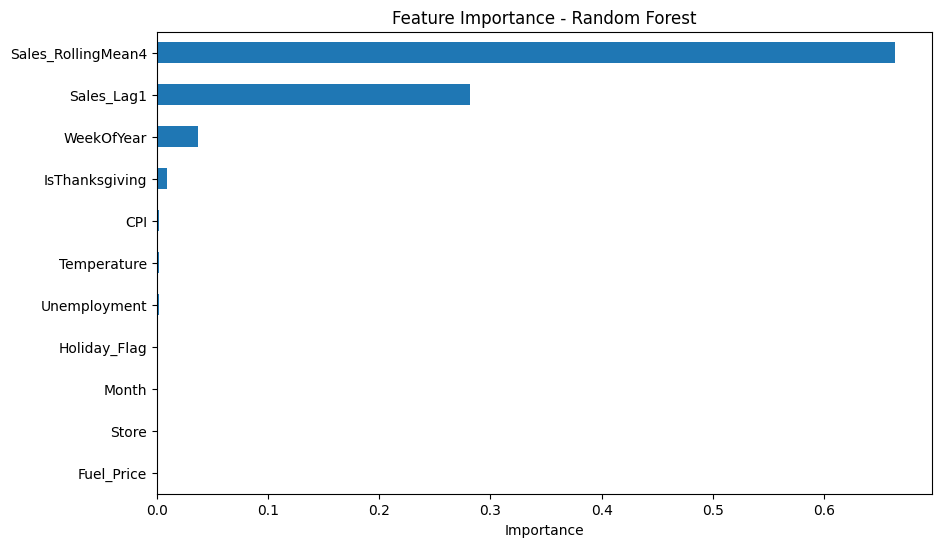

Sales_RollingMean4    0.663997
Sales_Lag1            0.281173
WeekOfYear            0.037339
IsThanksgiving        0.008901
CPI                   0.001708
Temperature           0.001489
Unemployment          0.001424
Holiday_Flag          0.001153
Month                 0.001085
Store                 0.001004
Fuel_Price            0.000726
dtype: float64


In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

print(importances)

In [ ]:
# Build a simple rule-based recommendation system on top of predictions
results = test.copy()
results['Predicted_Sales'] = preds_rf

def recommend_action(row):
    if row['Predicted_Sales'] > row['Sales_RollingMean4'] * 1.15:
        return 'Increase stock + hold price (demand surge expected)'
    elif row['Predicted_Sales'] < row['Sales_RollingMean4'] * 0.85:
        return 'Reduce price / promo (demand drop expected)'
    else:
        return 'Maintain current stock and price'

results['Recommendation'] = results.apply(recommend_action, axis=1)

results[['Store', 'Date', 'Weekly_Sales', 'Predicted_Sales', 'Recommendation']].head(15)

,Store,Date,Weekly_Sales,Predicted_Sales,Recommendation
109,1,2012-04-06,1899676.88,1.607129e+06,Maintain current stock and price
110,1,2012-04-13,1621031.70,1.724498e+06,Maintain current stock and price
111,1,2012-04-20,1521577.87,1.643005e+06,Maintain current stock and price
112,1,2012-04-27,1468928.37,1.631488e+06,Maintain current stock and price
113,1,2012-05-04,1684519.99,1.570849e+06,Maintain current stock and price
114,1,2012-05-11,1611096.05,1.556968e+06,Maintain current stock and price
115,1,2012-05-18,1595901.87,1.555300e+06,Maintain current stock and price
116,1,2012-05-25,1555444.55,1.588207e+06,Maintain current stock and price
117,1,2012-06-01,1624477.58,1.593696e+06,Maintain current stock and price
118,1,2012-06-08,1697230.96,1.592072e+06,Maintain current stock and price


In [ ]:
# Tighter thresholds to see more action
def recommend_action_v2(row):
    if row['Predicted_Sales'] > row['Sales_RollingMean4'] * 1.05:
        return 'Increase stock (demand rising)'
    elif row['Predicted_Sales'] < row['Sales_RollingMean4'] * 0.95:
        return 'Reduce price / promo (demand softening)'
    else:
        return 'Maintain current stock and price'

results['Recommendation'] = results.apply(recommend_action_v2, axis=1)

# Check the distribution of recommendations
print(results['Recommendation'].value_counts())

# Show a mix of examples - some near holidays if any fall in test period
results[['Store', 'Date', 'Weekly_Sales', 'Predicted_Sales', 'Sales_RollingMean4', 'Recommendation']].sample(15, random_state=1)

Recommendation
Maintain current stock and price           1255
Reduce price / promo (demand softening)      52
Increase stock (demand rising)               43
Name: count, dtype: int64


,Store,Date,Weekly_Sales,Predicted_Sales,Sales_RollingMean4,Recommendation
2914,21,2012-09-28,647097.65,6.659617e+05,6.755852e+05,Maintain current stock and price
3316,24,2012-06-15,1364445.98,1.384809e+06,1.395186e+06,Maintain current stock and price
2208,16,2012-07-13,569005.06,6.007737e+05,5.909293e+05,Maintain current stock and price
2630,19,2012-08-17,1375101.26,1.359476e+06,1.329405e+06,Maintain current stock and price
4014,29,2012-07-06,578832.41,5.501287e+05,5.610601e+05,Maintain current stock and price
5673,41,2012-05-04,1359770.73,1.306143e+06,1.313251e+06,Maintain current stock and price
5825,42,2012-08-03,573084.71,5.500550e+05,5.733679e+05,Maintain current stock and price
387,3,2012-04-06,503232.13,4.296470e+05,4.195835e+05,Maintain current stock and price
4990,36,2012-07-27,279643.43,3.155414e+05,2.999341e+05,Increase stock (demand rising)
527,4,2012-04-13,2105301.39,2.171924e+06,2.216537e+06,Maintain current stock and price


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Walmart Sales Forecast & Pricing Dashboard", layout="wide")
st.title("🛒 Walmart Sales Forecasting & Pricing Recommendation Dashboard")

st.markdown("""
This dashboard predicts next week's sales for a selected store and recommends
stock/pricing actions based on the prediction vs recent trend.
""")

# Load saved data and model (we'll create these in the next step)
results = pd.read_csv('results.csv', parse_dates=['Date'])

store_list = sorted(results['Store'].unique())
selected_store = st.selectbox("Select Store", store_list)

store_data = results[results['Store'] == selected_store].sort_values('Date')

col1, col2, col3 = st.columns(3)
col1.metric("Avg Weekly Sales", f"${store_data['Weekly_Sales'].mean():,.0f}")
col2.metric("Avg Predicted Sales", f"${store_data['Predicted_Sales'].mean():,.0f}")
col3.metric("Model MAPE", "4.85%")

st.subheader(f"Actual vs Predicted Sales — Store {selected_store}")
st.line_chart(store_data.set_index('Date')[['Weekly_Sales', 'Predicted_Sales']])

st.subheader("Latest Recommendations")
st.dataframe(
    store_data[['Date', 'Weekly_Sales', 'Predicted_Sales', 'Recommendation']].tail(10),
    use_container_width=True
)

Writing app.py


In [ ]:
# Save the results dataframe so app.py can load it
results.to_csv('results.csv', index=False)
print("Saved! Rows:", len(results))
print(results.columns.tolist())

Saved! Rows: 1350
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Sales_Lag1', 'Sales_RollingMean4', 'WeekOfYear', 'IsThanksgiving', 'Predicted_Sales', 'Recommendation']


In [ ]:
!pip install streamlit -q
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok
import subprocess
import time

ngrok.set_auth_token("3FZlTQGp2BwrusyIlljuEOXtkJk_35QjykgHawFPSnYVvt2Jf")

!pkill -f streamlit

subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])
time.sleep(5)

public_url = ngrok.connect(8501)
print("Your dashboard URL:", public_url)

Your dashboard URL: NgrokTunnel: "https://wasabi-strike-strudel.ngrok-free.dev" -> "http://localhost:8501"
